In [2]:
# GitHub repo installation of paddle
!python -m pip install paddlepaddle-gpu -i https://pypi.org/simple

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 759.0/759.0 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 2.5 MB/s eta 0:00:00
  Attempting uninstall: opt-einsum
    Found existing installation: opt_einsum 3.4.0
    Uninstalling opt_einsum-3.4.0:
      Successfully uninstalled opt_einsum-3.4.0


In [3]:
# Install paddle OCR
!pip install paddleocr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.8/297.8 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 969.6/969.6 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 49.8 MB/s eta 0:00:00
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=e3a1aefcf496c5581d1cbcfade0ddfe7fc2cc009607621d6ada9bde27e455f92
  Stored in directory: /root/.cache/pip/wheels/46/54/24/1624fd5b8674eb1188623f7e8e17cdf7c0f6c24b609dfb8a89
Successfully built fire


In [4]:
# Clone paddle OCR repo to get FONTS for visualization
!git clone https://github.com/PaddlePaddle/PaddleOCR

Cloning into 'PaddleOCR'...
remote: Enumerating objects: 139268, done.
remote: Counting objects: 100% (9637/9637), done.
remote: Compressing objects: 100% (1109/1109), done.
remote: Total 139268 (delta 9183), reused 8690 (delta 8528), pack-reused 129631 (from 4)
Receiving objects: 100% (139268/139268), 824.64 MiB | 23.28 MiB/s, done.
Resolving deltas: 100% (108803/108803), done.
Updating files: 100% (2028/2028), done.


In [8]:
from paddleocr import PaddleOCR, draw_ocr
import matplotlib.pyplot as plt
import cv2
import os
from PIL import Image, ImageDraw, ImageFont

In [6]:
ocr=PaddleOCR(use_angle_cls=True, lang='en')

download https://paddleocr.bj.bcebos.com/PP-OCRv3/english/en_PP-OCRv3_det_infer.tar to /root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer/en_PP-OCRv3_det_infer.tar


100%|██████████| 3910/3910 [00:11<00:00, 345.18it/s] 


download https://paddleocr.bj.bcebos.com/PP-OCRv4/english/en_PP-OCRv4_rec_infer.tar to /root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer/en_PP-OCRv4_rec_infer.tar


100%|██████████| 10000/10000 [00:13<00:00, 766.98it/s]


download https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar to /root/.paddleocr/whl/cls/ch_ppocr_mobile_v2.0_cls_infer/ch_ppocr_mobile_v2.0_cls_infer.tar


100%|██████████| 2138/2138 [00:07<00:00, 303.75it/s]

[2025/04/14 11:47:14] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_l

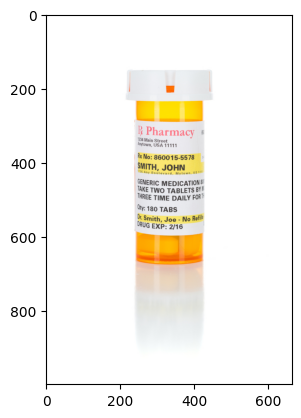

In [9]:
img_path="/content/drug.jpg"
image=Image.open(img_path).convert('RGB')
plt.imshow(image)

In [10]:
## Run the model on the ocr model
result=ocr.ocr(img_path,cls=True)

[2025/04/14 11:50:00] ppocr DEBUG: dt_boxes num : 6, elapsed : 1.043222188949585
[2025/04/14 11:50:00] ppocr DEBUG: cls num  : 6, elapsed : 0.0574493408203125
[2025/04/14 11:50:00] ppocr DEBUG: rec_res num  : 6, elapsed : 0.5733957290649414


In [11]:
result

[[[[[248.0, 301.0], [401.0, 311.0], [399.0, 336.0], [246.0, 326.0]],
   ('R Pharmacy', 0.9947571754455566)],
  [[[247.0, 329.0], [331.0, 337.0], [330.0, 352.0], [245.0, 344.0]],
   ('1234Main Street', 0.9621002674102783)],
  [[[246.0, 373.0], [404.0, 378.0], [403.0, 400.0], [246.0, 395.0]],
   ('Rx No:860015-5578', 0.9565625786781311)],
  [[[246.0, 398.0], [378.0, 403.0], [377.0, 428.0], [244.0, 423.0]],
   ('SMITH,JOHN', 0.9643214344978333)],
  [[[246.0, 511.0], [356.0, 518.0], [355.0, 540.0], [244.0, 533.0]],
   ('Qty:180 TABS', 0.9266524314880371)],
  [[[243.0, 555.0], [373.0, 565.0], [371.0, 590.0], [241.0, 580.0]],
   ('DRUG EXP:2/16', 0.9650620222091675)]]]

In [12]:
## Loop through the outer list and then the inner list to get all resultd

for line in result:
  print(line)

[[[[248.0, 301.0], [401.0, 311.0], [399.0, 336.0], [246.0, 326.0]], ('R Pharmacy', 0.9947571754455566)], [[[247.0, 329.0], [331.0, 337.0], [330.0, 352.0], [245.0, 344.0]], ('1234Main Street', 0.9621002674102783)], [[[246.0, 373.0], [404.0, 378.0], [403.0, 400.0], [246.0, 395.0]], ('Rx No:860015-5578', 0.9565625786781311)], [[[246.0, 398.0], [378.0, 403.0], [377.0, 428.0], [244.0, 423.0]], ('SMITH,JOHN', 0.9643214344978333)], [[[246.0, 511.0], [356.0, 518.0], [355.0, 540.0], [244.0, 533.0]], ('Qty:180 TABS', 0.9266524314880371)], [[[243.0, 555.0], [373.0, 565.0], [371.0, 590.0], [241.0, 580.0]], ('DRUG EXP:2/16', 0.9650620222091675)]]


In [13]:
# Loop through the outer list and then the inner list to get all results
for outer in result:
    for res in outer:
        print(res[1][1])  # This will print the confidence score

0.9947571754455566
0.9621002674102783
0.9565625786781311
0.9643214344978333
0.9266524314880371
0.9650620222091675


In [14]:
boxes=[res[0] for outer in result for res in outer]
txts=[res[1][0] for outer in result for res in outer]
scores=[res[1][1] for outer in result for res in outer]

In [15]:
boxes

[[[248.0, 301.0], [401.0, 311.0], [399.0, 336.0], [246.0, 326.0]],
 [[247.0, 329.0], [331.0, 337.0], [330.0, 352.0], [245.0, 344.0]],
 [[246.0, 373.0], [404.0, 378.0], [403.0, 400.0], [246.0, 395.0]],
 [[246.0, 398.0], [378.0, 403.0], [377.0, 428.0], [244.0, 423.0]],
 [[246.0, 511.0], [356.0, 518.0], [355.0, 540.0], [244.0, 533.0]],
 [[243.0, 555.0], [373.0, 565.0], [371.0, 590.0], [241.0, 580.0]]]

In [16]:
txts

['R Pharmacy',
 '1234Main Street',
 'Rx No:860015-5578',
 'SMITH,JOHN',
 'Qty:180 TABS',
 'DRUG EXP:2/16']

In [17]:
scores

[0.9947571754455566,
 0.9621002674102783,
 0.9565625786781311,
 0.9643214344978333,
 0.9266524314880371,
 0.9650620222091675]

In [23]:
from paddleocr import PaddleOCR, draw_ocr

# Initialize the OCR model
ocr_model = PaddleOCR(use_angle_cls=True, lang='en')  # or 'en', 'ch', etc.


[2025/04/14 12:04:16] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_text_l

**Visualization the prediction**

In [18]:
font_path="/content/OpenSans_Condensed-Italic.ttf"

In [19]:
img=cv2.imread(img_path)
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
img.shape

(1000, 664, 3)

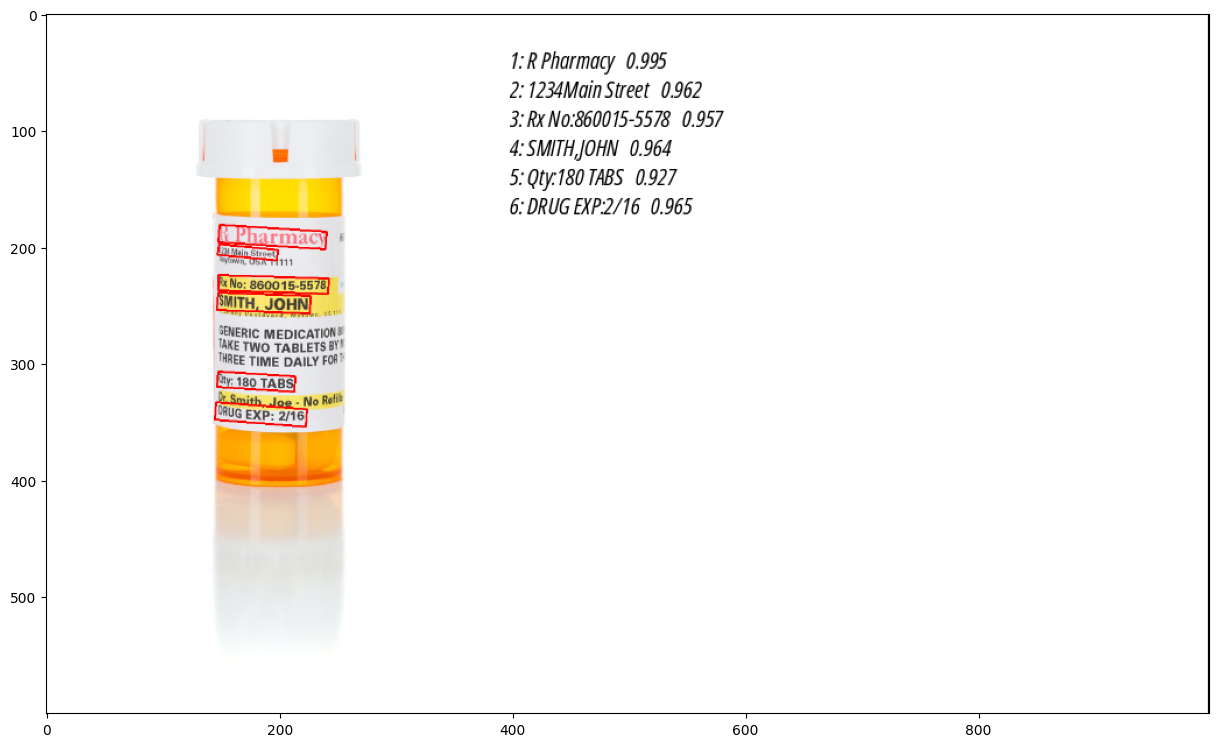

In [20]:
plt.figure(figsize=(15,15))

## Draw annotations on image
annotated=draw_ocr(img,boxes,txts,scores,font_path=font_path)
plt.imshow(annotated)

# Automated text Extraction on Samples

In [26]:
def perform_ocr_and_visualize(img_path, ocr_model, font_path):
    """
    Function to perform OCR on an image, extract detected components, and visualize the results.

    Parameters:
    - img_path: Path to the input image
    - ocr_model: Initialized PaddleOCR model
    - font_path: Path to the font file for visualization
    """
    RESULT = ocr_model.ocr(img_path, cls=True)

    # Extract bounding boxes, texts, and scores from nested structure
    boxes = [res[0] for outer in RESULT for res in outer]
    txts = [res[1][0] for outer in RESULT for res in outer]
    scores = [res[1][1] for outer in RESULT for res in outer]

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(15, 15))
    annotated = draw_ocr(img, boxes, txts, scores, font_path=font_path)
    plt.imshow(annotated)
    plt.axis('off')
    plt.show()



[2025/04/14 12:04:35] ppocr DEBUG: dt_boxes num : 5, elapsed : 0.0890512466430664
[2025/04/14 12:04:35] ppocr DEBUG: cls num  : 5, elapsed : 0.04034781455993652
[2025/04/14 12:04:36] ppocr DEBUG: rec_res num  : 5, elapsed : 0.4654123783111572


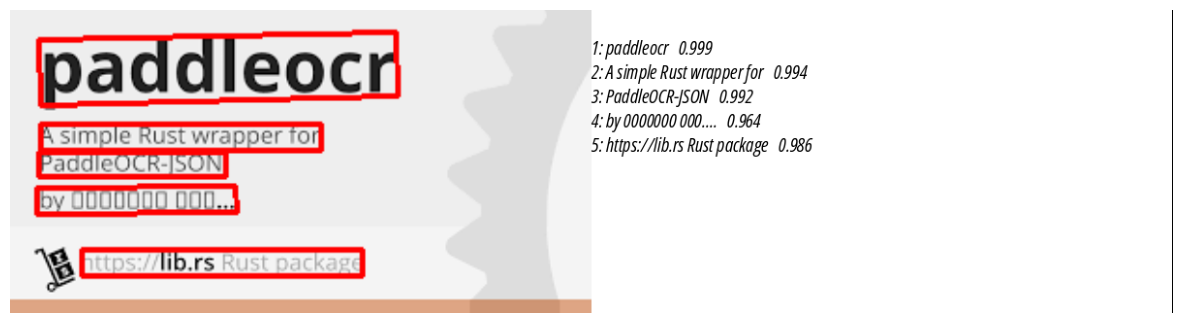

In [27]:
# Another image exampe1:
img_path = '/content/images.png'

# Call the function with the updated img_path and ocr_model
perform_ocr_and_visualize(img_path, ocr_model, font_path)